Important the Dependeties

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.datasets import load_iris


Importing the Boston House Price DataSet

In [19]:
# Loading the dataset to a Pandas DataFrame
house_price_prediction = pd.read_csv("housing.csv")

In [20]:
# Print First 5 rows to our DataFrame
house_price_prediction.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [26]:
# add the target (price) column to the DataFrame
house_price_prediction['price'] = 100000

In [23]:
print(house_price_prediction.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


In [24]:
house_price_prediction['price'] = 100000

In [25]:
house_price_prediction

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,price
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,100000
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,100000
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,100000
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,100000
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,100000
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,100000
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,100000
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,100000
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,100000


In [27]:
house_price_prediction.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,price
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,100000
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,100000
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,100000
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,100000
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,100000


In [28]:
# Checking the number of rows and Columns in the Data Frame
house_price_prediction.shape

(20640, 11)

In [30]:
# checking the Missing Values
house_price_prediction.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
price                   0
dtype: int64

In [31]:
# Fill Missing Values in DataSet
house_price_prediction['total_bedrooms'].fillna(house_price_prediction['total_bedrooms'].mean(), inplace=True)

/var/folders/qj/jhdzh4bd3wj28qd2dgxdbhmw0000gn/T/ipykernel_15849/3678260286.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  house_price_prediction['total_bedrooms'].fillna(house_price_prediction['total_bedrooms'].mean(), inplace=True)


In [33]:
# Again checking the Missing Value is Fill or not
house_price_prediction.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
price                 0
dtype: int64

In [34]:
# Statistical measures of the DataFrame
house_price_prediction.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.0
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,100000.0
std,2.003532,2.135952,12.585558,2181.615252,419.266592,1132.462122,382.329753,1.899822,115395.615874,0.0
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,100000.0
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000,100000.0
50%,-118.490000,34.260000,29.000000,2127.000000,438.000000,1166.000000,409.000000,3.534800,179700.000000,100000.0
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000,100000.0
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,100000.0


Understand the Correlation between various features in the dataset


1.Positive Correlation








2.Negative Correlation

In [39]:
correlation = house_price_prediction.corr()

In [38]:
# Label Encoding
house_price_prediction.replace({"ocean_proximity":{"NEAR BAY":0,"INLAND":1,"<1H OCEAN":2,"NEAR OCEAN":3,"ISLAND":4}}, inplace=True)

/var/folders/qj/jhdzh4bd3wj28qd2dgxdbhmw0000gn/T/ipykernel_15849/2857055129.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  house_price_prediction.replace({"ocean_proximity":{"NEAR BAY":0,"INLAND":1,"<1H OCEAN":2,"NEAR OCEAN":3,"ISLAND":4}}, inplace=True)


In [40]:
correlation = house_price_prediction.corr()

<Axes: >

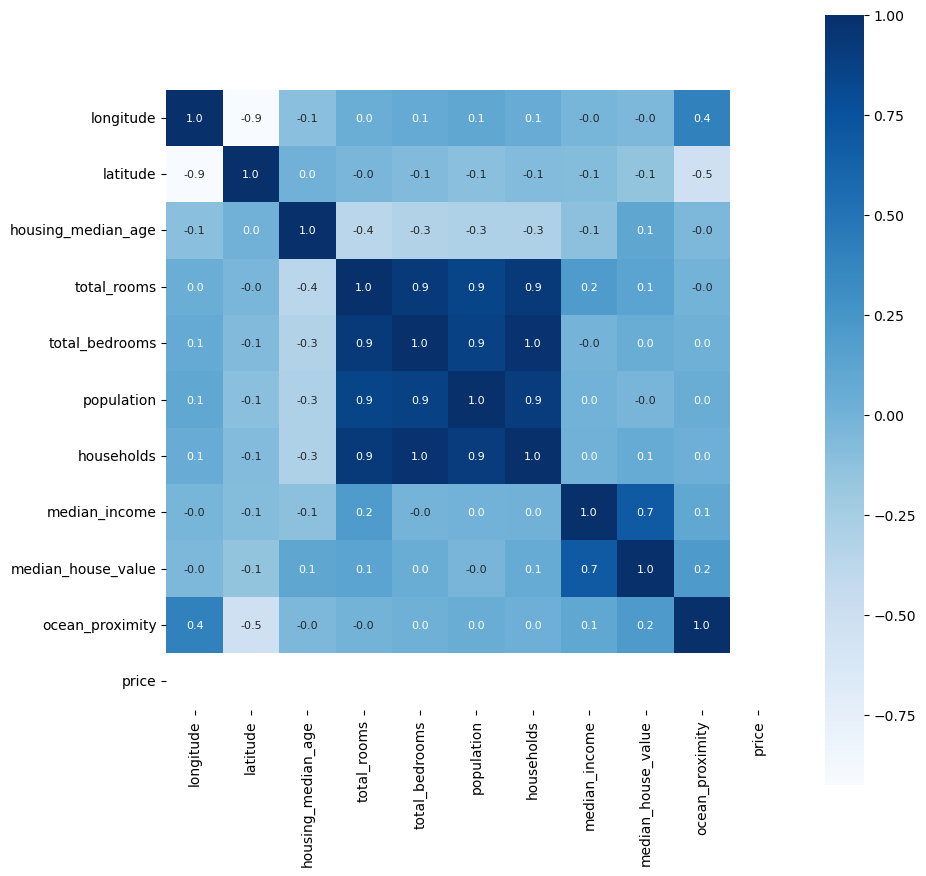

In [41]:
# Constructing a heatmap to understand the correalation
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8}, cmap='Blues')

Splitting the data and Target

In [44]:
X = house_price_prediction.drop(['price'], axis=1)
Y = house_price_prediction['price']

In [45]:
print(X)
print(Y)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
2        -122.24     37.85                52.0       1467.0           190.0   
3        -122.25     37.85                52.0       1274.0           235.0   
4        -122.25     37.85                52.0       1627.0           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  households  median_income  media

Splitting the data into Training data and Test data

In [60]:
X_train, X_test,y_train,Y_test = train_test_split(X,Y, test_size=0.2, stratify=Y, random_state=2)

In [61]:
print(X.shape,X_train.shape,X_test.shape)

(20640, 10) (16512, 10) (4128, 10)


Model Training













XGB Booster Regressor

In [62]:
# Loading the Model
model = XGBRegressor

In [66]:
# training the model with X_train
from xgboost import XGBRegressor


model = XGBRegressor()

model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluation
















Prediction on training data

In [67]:
# Accuracy for prediction on training data
training_data_prediction = model.predict(X_train)

In [68]:
print('training_data_prediction :',training_data_prediction)

training_data_prediction : [100000. 100000. 100000. ... 100000. 100000. 100000.]


In [69]:
# R squared error
score_1 = metrics.r2_score(Y_train, training_data_prediction)


# Mean absolute error
score_2 = metrics.mean_absolute_error(Y_train, training_data_prediction)

print('R squared error  :',score_1)
print('Mean absolute error :',score_2)

R squared error  : 1.0
Mean absolute error : 0.0


Visualizing the actual Prices and Predicted Prices

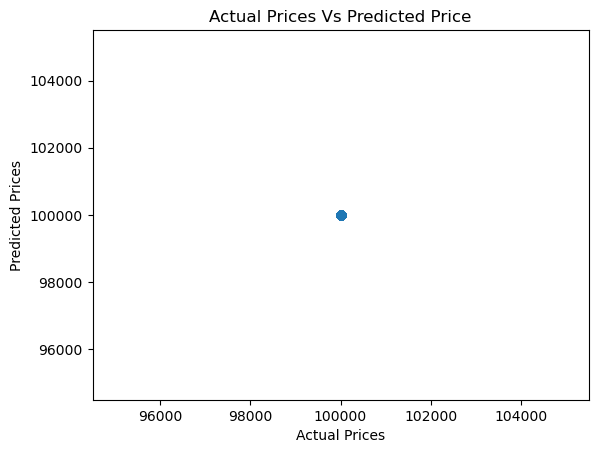

In [74]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices Vs Predicted Price")
plt.show()

Prediction on Test Data

In [72]:
# Accuracy for prediction on test data
test_data_prediction = model.predict(X_test)

In [73]:
# R squared error
score_1 = metrics.r2_score(Y_test, test_data_prediction)

# Mean Absolute error
score_2 = metrics.mean_absolute_error(Y_test, test_data_prediction)

print('R squared error :',score_1)
print('Mean Absolute error :',score_2)

R squared error : 1.0
Mean Absolute error : 0.0
